=== СТРУКТУРА ДАННЫХ ===
Столбцы метаданных: ['DATASET', 'SERIES_CODE', 'OBS_MEASURE', 'COUNTRY', 'INDICATOR', 'FREQUENCY', 'SCALE']
Диапазон лет: 1979 - 2031 (53 лет)

=== ПОСЛЕ ТРАНСФОРМАЦИИ ===
Размерность: (6784, 9)

=== ДОСТУПНОСТЬ ДАННЫХ ===
Наблюдений с Gross debt: 954
Наблюдений с Net lending/borrowing: 1908

=== РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ===
GROUP
Low-Income Developing    428
Emerging Markets         420
Advanced Economies       155
G7/G20                   142
Oil Producers             82
World                     74
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_8844\272564115.py:257: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_8844\272564115.py:258: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.savefig('phase_portraits_analysis.png', dpi=300, bbox_inches='tight')
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


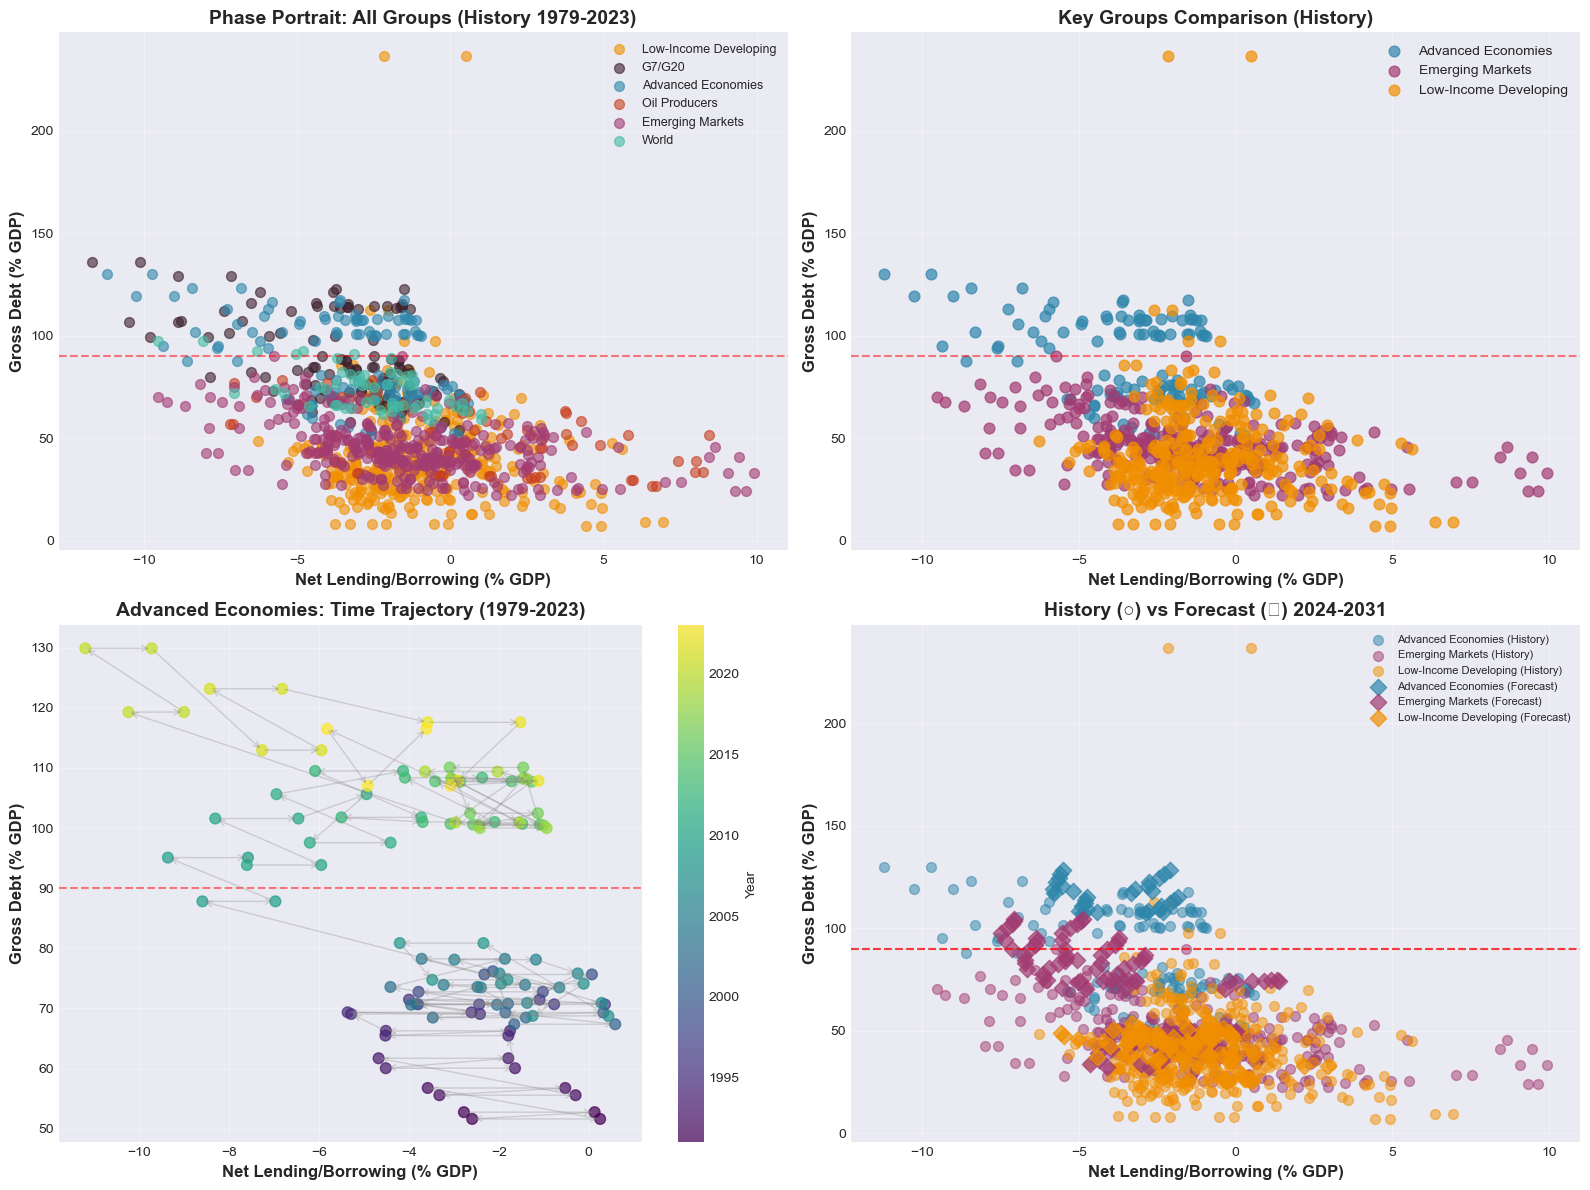


 АНАЛИЗ ЗАВЕРШЕН
 График сохранен: phase_portraits_analysis.png
 Размерность данных: 1301 наблюдений
 Диапазон лет: 1990 - 2031
 Групп стран: 6


In [14]:

# ФИНАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ПАЙПЛАЙН
# Фазовые портреты фискальной динамики: Долг vs Дефицит

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = 'dataset_2026-09-30T18_12_48_858129640Z_DEFAULT_INTEGRATION_IMF_FAD_FM_5_0_0.csv'
df_wide = pd.read_csv(file_path)

# Антихрупкое разделение метаданных и временных рядов
id_cols = [c for c in df_wide.columns if not c.isdigit()]
year_cols = [c for c in df_wide.columns if c.isdigit()]

print(f"=== СТРУКТУРА ДАННЫХ ===")
print(f"Столбцы метаданных: {id_cols}")
print(f"Диапазон лет: {min(year_cols)} - {max(year_cols)} ({len(year_cols)} лет)")


df_long = df_wide.melt(
    id_vars=id_cols, 
    value_vars=year_cols, 
    var_name='YEAR', 
    value_name='VALUE'
)

df_long['YEAR'] = df_long['YEAR'].astype(int)

print(f"\n=== ПОСЛЕ ТРАНСФОРМАЦИИ ===")
print(f"Размерность: {df_long.shape}")


# Gross debt (государственный долг)
debt_mask = df_long['INDICATOR'].str.contains('Gross debt', case=False, na=False)
df_debt = df_long[debt_mask][['COUNTRY', 'YEAR', 'VALUE']].copy()
df_debt.rename(columns={'VALUE': 'GROSS_DEBT'}, inplace=True)

# Net lending/borrowing (фискальный баланс/дефицит)
balance_mask = df_long['INDICATOR'].str.contains('Net lending.*net borrowing', case=False, na=False)
df_balance = df_long[balance_mask][['COUNTRY', 'YEAR', 'VALUE']].copy()
df_balance.rename(columns={'VALUE': 'NET_LENDING'}, inplace=True)

print(f"\n=== ДОСТУПНОСТЬ ДАННЫХ ===")
print(f"Наблюдений с Gross debt: {len(df_debt)}")
print(f"Наблюдений с Net lending/borrowing: {len(df_balance)}")

ax4 = axes[1, 1]

# История (круги)
history_key = history_data[history_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = history_key[history_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (History)',
        alpha=0.5,
        s=50,
        marker='o'
    )

# Прогноз (ромбы вместо треугольников — совместимо с Arial)
forecast_data = df_phase[df_phase['IS_FORECAST']]
forecast_key = forecast_data[forecast_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = forecast_key[forecast_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (Forecast)',
        alpha=0.7,
        s=70,
        marker='D'  # ← ИЗМЕНЕНО: 'D' (ромб) вместо '^' (треугольник)
    )

ax4.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax4.set_title('History (○) vs Forecast (◆) 2024-2031', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)

def classify_country(country):
    """Классификация стран по группам МВФ"""
    if 'Advanced' in country:
        return 'Advanced Economies'
    elif 'Emerging' in country or 'Middle-Income' in country:
        return 'Emerging Markets'
    elif 'Low-Income' in country:
        return 'Low-Income Developing'
    elif 'Oil Producers' in country:
        return 'Oil Producers'
    elif 'G7' in country or 'G20' in country:
        return 'G7/G20'
    elif 'World' in country:
        return 'World'
    else:
        return 'Other'

df_phase['GROUP'] = df_phase['COUNTRY'].apply(classify_country)

# Разделение на историю и прогноз (граница 2023)
df_phase['IS_FORECAST'] = df_phase['YEAR'] > 2023

print(f"\n=== РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ===")
print(df_phase['GROUP'].value_counts())


# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Цветовая палитра
palette = {
    'Advanced Economies': '#2E86AB',
    'Emerging Markets': '#A23B72',
    'Low-Income Developing': '#F18F01',
    'Oil Producers': '#C73E1D',
    'G7/G20': '#3B1F2B',
    'World': '#44BBA4',
    'Other': 'gray'
}

# Ключевые группы для сравнения
key_groups = ['Advanced Economies', 'Emerging Markets', 'Low-Income Developing']
history_data = df_phase[~df_phase['IS_FORECAST']]

ax1 = axes[0, 0]

for group in history_data['GROUP'].unique():
    group_data = history_data[history_data['GROUP'] == group]
    ax1.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=group,
        alpha=0.6,
        s=50
    )

ax1.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax1.set_title('Phase Portrait: All Groups (History 1979-2023)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='Critical threshold (90%)')
ax1.grid(True, alpha=0.3)


ax2 = axes[0, 1]
key_data = history_data[history_data['GROUP'].isin(key_groups)]

for group in key_groups:
    group_data = key_data[key_data['GROUP'] == group]
    ax2.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=group,
        alpha=0.7,
        s=60
    )

ax2.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax2.set_title('Key Groups Comparison (History)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)


ax3 = axes[1, 0]
advanced_data = history_data[history_data['GROUP'] == 'Advanced Economies'].sort_values('YEAR')

# Scatter с цветовым градиентом по времени
scatter = ax3.scatter(
    advanced_data['NET_LENDING'], 
    advanced_data['GROSS_DEBT'], 
    c=advanced_data['YEAR'], 
    cmap='viridis',
    alpha=0.7,
    s=60
)

# Стрелки для показа направления
for i in range(len(advanced_data) - 1):
    ax3.annotate(
        '', 
        xy=(advanced_data.iloc[i+1]['NET_LENDING'], advanced_data.iloc[i+1]['GROSS_DEBT']),
        xytext=(advanced_data.iloc[i]['NET_LENDING'], advanced_data.iloc[i]['GROSS_DEBT']),
        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.3)
    )

ax3.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax3.set_title('Advanced Economies: Time Trajectory (1979-2023)', fontsize=14, fontweight='bold')
ax3.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Year', fontsize=10)


ax4 = axes[1, 1]

ax4 = axes[1, 1]

# История (круги)
history_key = history_data[history_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = history_key[history_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (History)',
        alpha=0.5,
        s=50,
        marker='o'
    )

# Прогноз (ромбы вместо треугольников — совместимо с Arial)
forecast_data = df_phase[df_phase['IS_FORECAST']]
forecast_key = forecast_data[forecast_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = forecast_key[forecast_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (Forecast)',
        alpha=0.7,
        s=70,
        marker='D'  # ← ИЗМЕНЕНО: 'D' (ромб) вместо '^' (треугольник)
    )

ax4.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax4.set_title('History (○) vs Forecast (◆) 2024-2031', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)

ax4.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax4.set_title('History (○) vs Forecast (△) 2024-2031', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)



plt.tight_layout()
plt.savefig('phase_portraits_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print(" АНАЛИЗ ЗАВЕРШЕН")
print("="*70)
print(f" График сохранен: phase_portraits_analysis.png")
print(f" Размерность данных: {df_phase.shape[0]} наблюдений")
print(f" Диапазон лет: {df_phase['YEAR'].min()} - {df_phase['YEAR'].max()}")
print(f" Групп стран: {df_phase['GROUP'].nunique()}")
print("="*70)